# Looming: distance & velocity from one microphone

*2026-07-09* Roberto Barumerli

**Question:** during the `looming and receding` flights, can we estimate how far the
drone is and how fast it is closing?

**Flight protocol** (per cycle): take off ~3 m from Spot → fly toward Spot → hover
around Spot → recede back to the start → stop. The microphone sits at/near Spot.

**Assessment up front:**

- The **detector score and the comb correlation cannot do distance** — and that is by
  design, not an accident: the whole detection pipeline *whitens* the spectrum
  (subtracts the local floor), which makes it deliberately blind to loudness. Once the
  drone is airborne both signals saturate (step 2 shows it).
- **Doppler is numerically hopeless** here: at ~0.5 m/s the shift is 0.15 % of the
  frequency, while the rotors' own RPM wobble is ±2 % — 15× larger (step 2).
- What *does* work is the user's fallback: **loudness, band-limited to 8–16 kHz** —
  the drone's broadband prop wash, in a band the crowd can't reach. Free-field physics
  (1/r²) gives −6 dB per doubling of distance, so level → relative distance, its slope →
  radial velocity, and `8.686 / slope` → **time-to-contact τ**, which needs *no
  calibration at all* and is exactly the looming signal biology uses.
- Results on the three recorded cycles (anchoring "3 m" at detection onset): cycle 2
  shows a textbook arc 3 m → **1.2 m** → back, approach speed up to **0.5 m/s**, τ down
  to **4 s**; cycle 3 a gentler 3 m → **1.6 m**; cycle 1's level is flat — that pass
  never actually closed on the microphone.

Everything below runs causally (hop by hop), so it drops straight into
`06_realtime_detector.py`.

In [1]:
import importlib.util
from collections import deque
from pathlib import Path

import numpy as np
import scipy.signal as sig
import soundfile as sf
import matplotlib.pyplot as plt

# reuse the EXACT live pipeline (whitening, calibration, detector) from the script
_spec = importlib.util.spec_from_file_location("rt", "06_realtime_detector.py")
rt = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(rt)
FS, HOP_S = rt.FS, rt.HOP_S

# ---------- the knobs ----------
R0          = 3.0             # meters at takeoff (flight protocol)
LEV_LO, LEV_HI = 8000, 16000  # level band: drone prop wash, above crowd reach
SLOPE_WIN_S = 4.0             # window for the level slope (dB/s)
DEADBAND    = 0.3             # |dB/s| below this = "hover"
REF_S       = 2.0             # level averaged this long after detection = R0 anchor

REC = Path("recordings with big drone")
cal = np.load("drone_cal.npz")           # session-2 calibration (crowd background)
W_BG, THR_ON = cal["w_bg"], float(cal["thr_on"])

COL = dict(blue="#2a78d6", aqua="#1baf7a", yellow="#eda100", red="#e34948",
           ink="#0b0b0b", ink2="#52514e", muted="#898781",
           grid="#e1e0d9", baseline="#c3c2b7")
plt.rcParams.update({
    "axes.edgecolor": COL["baseline"], "axes.labelcolor": COL["ink2"],
    "axes.grid": True, "grid.color": COL["grid"], "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": COL["ink2"], "ytick.color": COL["ink2"],
    "text.color": COL["ink"], "font.size": 10.5,
    "axes.titlesize": 11.5, "axes.titlelocation": "left",
    "legend.frameon": False, "figure.dpi": 100})

print(f"pipeline loaded, THR_ON = {THR_ON:.2f} dB")

pipeline loaded, THR_ON = 1.41 dB


## Step 1 — detection flag + band level, causally

One pass per file, hop by hop like the live script: the detector gives the *drone
present* flag, and from the same 0.1-s buffer we take the raw (un-whitened) mean level
in 8–16 kHz. The room floor in that band comes from the non-detected windows — anything
above it, while the flag is on, is drone.

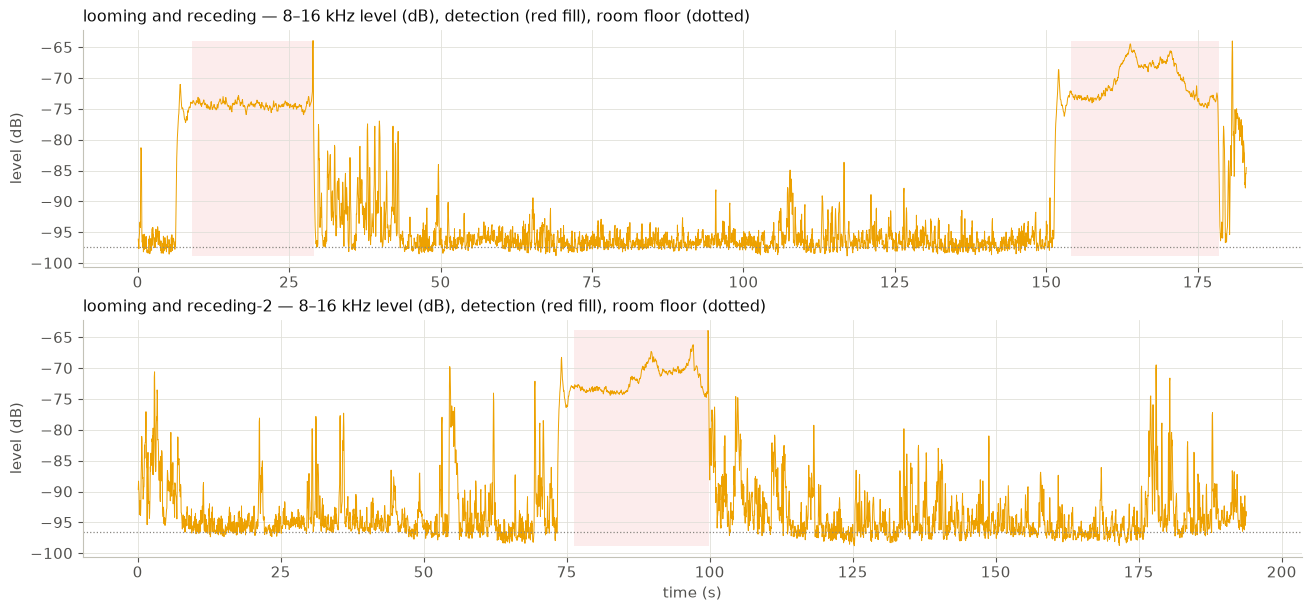

In [2]:
def run_file(path):
    """Causal replay: (t, level_dB, detected) per hop."""
    x, fs = sf.read(path)
    det = rt.LiveDroneDetector(W_BG, THR_ON)
    t, lev, flag = [], [], []
    for i in range(0, len(x) - rt.HOP, rt.HOP):
        m = det.feed(x[i:i + rt.HOP])
        if m is None:
            continue
        f, _, Z = sig.stft(det.buf, fs, nperseg=rt.NPERSEG, noverlap=rt.NPERSEG // 2)
        P = np.mean(np.abs(Z) ** 2, axis=1)
        lev.append(10 * np.log10(P[(f > LEV_LO) & (f < LEV_HI)].mean() + 1e-18))
        t.append((i + rt.HOP) / fs)
        flag.append(m["on"])
    return np.array(t), np.array(lev), np.array(flag, bool)

FILES = ["looming and receding", "looming and receding-2"]
runs = {nm: run_file(REC / f"{nm}.wav") for nm in FILES}
FLOOR = {nm: np.percentile(lev[~flag], 20) for nm, (t, lev, flag) in runs.items()}

fig, axes = plt.subplots(2, 1, figsize=(13, 6), constrained_layout=True)
for ax, nm in zip(axes, FILES):
    t, lev, flag = runs[nm]
    ax.fill_between(t, lev.min(), lev.max(), where=flag, color=COL["red"], alpha=0.10, lw=0)
    ax.plot(t, lev, lw=0.7, color=COL["yellow"])
    ax.axhline(FLOOR[nm], color=COL["muted"], lw=0.9, ls=":")
    ax.set_title(f"{nm} — 8–16 kHz level (dB), detection (red fill), room floor (dotted)")
    ax.set_ylabel("level (dB)")
axes[1].set_xlabel("time (s)")
plt.show()

The takeoff step is ~20 dB; on top of it the approach adds a smooth hump —
that hump is the distance signal. Cycle 1 (first block of the first file) has no hump:
that pass never came closer to the microphone.

## Step 2 — why not the comb filter (and not Doppler)

The natural hope: the detection score or the comb correlation should grow as the drone
approaches. They do — for the first second. Then they **saturate**: whitening measures
peaks *relative to the local floor*, so once the harmonics are safely above it,
"clearly there at 3 m" and "clearly there at 1 m" look the same. The comb correlation is
additionally bounded at 1 by construction. Both are *presence* signals, not *range*
signals — the plot below shows them flat-topping over the best loom-recede cycle while
the raw level traces the whole arc.

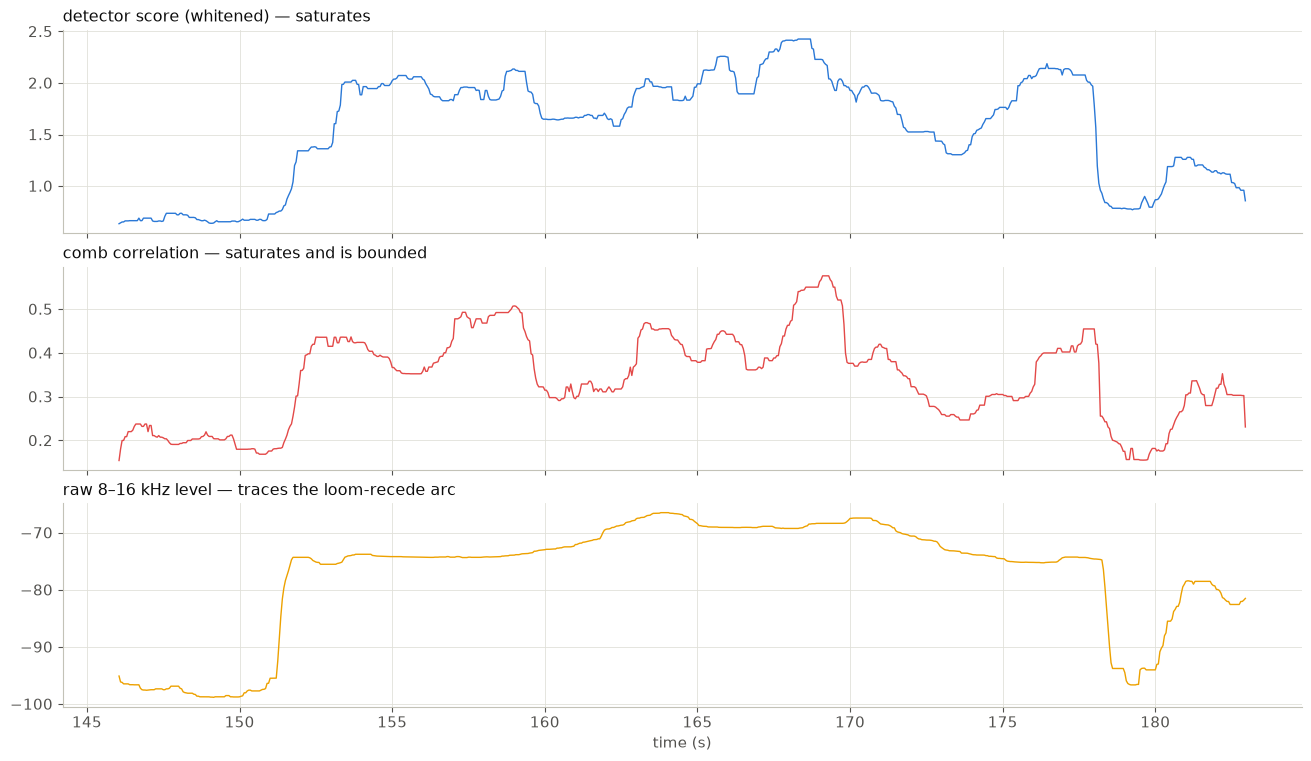

Doppler at 0.5 m/s: 0.15 % frequency shift
observed rotor RPM wobble: ~2 %  ->  14x larger. Doppler is unusable here.


In [3]:
# recompute score + comb corr over the clearest cycle (file 1, ~146-184 s)
x, fs = sf.read(REC / "looming and receding.wav")
seg = slice(int(146 * fs), int(184 * fs))
xw = x[seg]
n, h = int(rt.WIN_S * fs), rt.HOP
ts, sc, cc, lv = [], [], [], []
for i in range(0, len(xw) - n, h):
    win = xw[i:i + n]
    f, _, Z = sig.stft(win, fs, nperseg=rt.NPERSEG, noverlap=rt.NPERSEG // 2)
    P = np.mean(np.abs(Z) ** 2, axis=1)
    Ldb = 10 * np.log10(P + 1e-18)
    Li = np.interp(rt.LOGF, f, Ldb)
    E = np.maximum(Li - sig.medfilt(Li, rt.MED_BINS) - W_BG, 0)
    En = E - E.mean()
    ts.append(146 + (i + n / 2) / fs)
    sc.append(E[rt.SCORE_BAND].mean())
    cc.append(float((rt.TPL_BANK @ En / (np.linalg.norm(En) + 1e-12)).max()))
    lv.append(Ldb[(f > LEV_LO) & (f < LEV_HI)].mean())
sm = lambda v: sig.medfilt(np.array(v), 21)

fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), sharex=True, constrained_layout=True)
for ax, v, c, ttl in [(axes[0], sm(sc), COL["blue"], "detector score (whitened) — saturates"),
                      (axes[1], sm(cc), COL["red"], "comb correlation — saturates and is bounded"),
                      (axes[2], sm(lv), COL["yellow"], "raw 8–16 kHz level — traces the loom-recede arc")]:
    ax.plot(ts, v, lw=1, color=c)
    ax.set_title(ttl)
axes[2].set_xlabel("time (s)")
plt.show()

# Doppler feasibility, in numbers
v_drone, c_sound = 0.5, 343.0
print(f"Doppler at {v_drone} m/s: {100 * v_drone / c_sound:.2f} % frequency shift")
print(f"observed rotor RPM wobble: ~2 %  ->  {2 / (100 * v_drone / c_sound):.0f}x larger. "
      "Doppler is unusable here.")

## Step 3 — level → distance

Free field: intensity ~ 1/r², i.e. the level in dB is `L = L₀ − 20·log₁₀(r/r₀)`.
Subtract the room floor (linear power) to get the drone-only level, anchor `r₀ = 3 m`
at the level right after detection onset (the protocol says the drone takes off ~3 m
away), and invert:

> **r(t) = 3 m × 10^(−(L(t) − L_ref) / 20)**

This is *relative* ranging — honest error budget: throttle changes and the prop-wash
radiation pattern move the level by ±3 dB, which is a ×1.4 distance error. Good enough
for near / mid / far, not a rangefinder.

cycle 1 (looming and receding): closest 2.80 m at t = 28.3 s
cycle 2 (looming and receding): closest 1.21 m at t = 164.1 s
cycle 3 (looming and receding-2): closest 1.62 m at t = 96.7 s


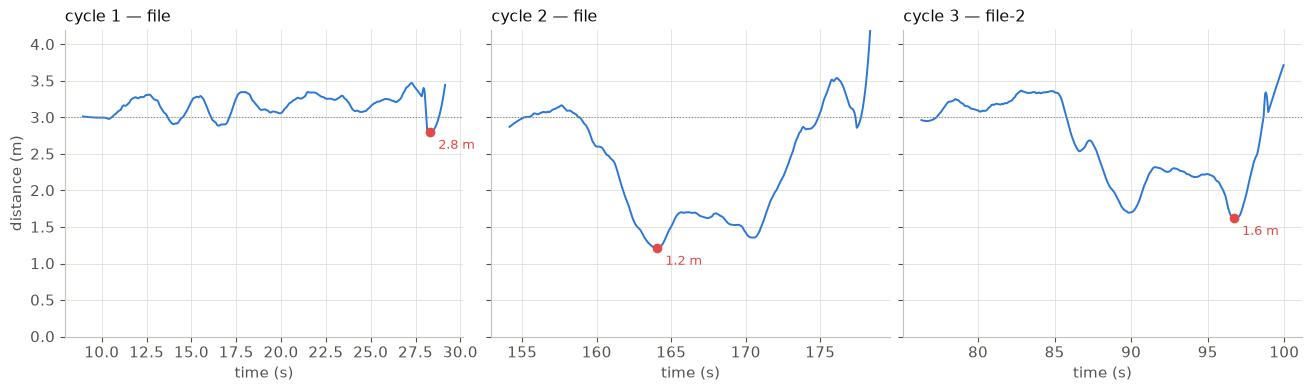

In [4]:
def segments_of(flag, t, min_s=5.0):
    segs, start = [], None
    for i, on in enumerate(flag):
        if on and start is None:
            start = i
        if not on and start is not None:
            if t[i - 1] - t[start] > min_s:
                segs.append((start, i))
            start = None
    if start is not None and t[-1] - t[start] > min_s:
        segs.append((start, len(flag)))
    return segs

def track_segment(t, lev, sl, floor_db):
    """Offline distance/velocity/tau for one detection segment."""
    ts, L = t[sl[0]:sl[1]], lev[sl[0]:sl[1]]
    Ls = sig.savgol_filter(L, 41, 2)                              # ~2 s smooth
    Ld = 10 * np.log10(np.maximum(10 ** (Ls / 10) - 10 ** (floor_db / 10), 1e-12))
    L_ref = np.median(Ld[:int(REF_S / HOP_S)])                    # first 2 s = R0
    r = R0 * 10 ** (-(Ld - L_ref) / 20)
    npts = int(SLOPE_WIN_S / HOP_S) // 2 * 2 + 1
    slope = sig.savgol_filter(L, npts, 2, deriv=1, delta=HOP_S)   # dB/s
    v = r * np.log(10) / 20 * slope                               # m/s, + = approaching
    tau = np.where(slope > DEADBAND, 8.686 / np.maximum(slope, 1e-3), np.nan)
    return ts, r, v, slope, tau

CYCLES = []
for nm in FILES:
    t, lev, flag = runs[nm]
    for sl in segments_of(flag, t):
        CYCLES.append((nm, track_segment(t, lev, sl, FLOOR[nm])))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True, constrained_layout=True)
for k, (ax, (nm, (ts, r, v, slope, tau))) in enumerate(zip(axes, CYCLES)):
    ax.plot(ts, r, lw=1.4, color=COL["blue"])
    ax.axhline(R0, color=COL["muted"], lw=0.8, ls=":")
    i = np.argmin(r)
    ax.plot(ts[i], r[i], "o", ms=6, color=COL["red"])
    ax.annotate(f"{r[i]:.1f} m", (ts[i], r[i]), textcoords="offset points",
                xytext=(6, -12), fontsize=9, color=COL["red"])
    ax.set_ylim(0, 4.2)
    ax.set_title(f"cycle {k + 1} — {nm.replace('looming and receding', 'file')}")
    ax.set_xlabel("time (s)")
    print(f"cycle {k + 1} ({nm}): closest {r.min():.2f} m at t = {ts[i]:.1f} s")
axes[0].set_ylabel("distance (m)")
plt.show()

## Step 4 — velocity and time-to-contact

Two readouts from the level slope (dB/s, Savitzky–Golay over ~4 s):

- **radial velocity** `v = r · ln10/20 · slope` (positive = approaching) — needs the
  distance estimate, so it inherits the anchor assumption;
- **time-to-contact** `τ = r / v = 8.686 / slope` — the anchor and the reference level
  *cancel out*: τ needs **no calibration whatsoever**. τ is what looming-sensitive
  neurons compute, and it is the natural duck trigger: it answers "how many seconds
  until it reaches me *if it keeps coming*".

A ±0.3 dB/s deadband turns the slope into a three-state readout:
**approaching / hover / receding**.

cycle 1: peak approach 0.30 m/s, peak recede -0.11 m/s, min τ 11.6 s
cycle 2: peak approach 0.46 m/s, peak recede -0.47 m/s, min τ 4.3 s
cycle 3: peak approach 0.34 m/s, peak recede -1.47 m/s, min τ 7.2 s


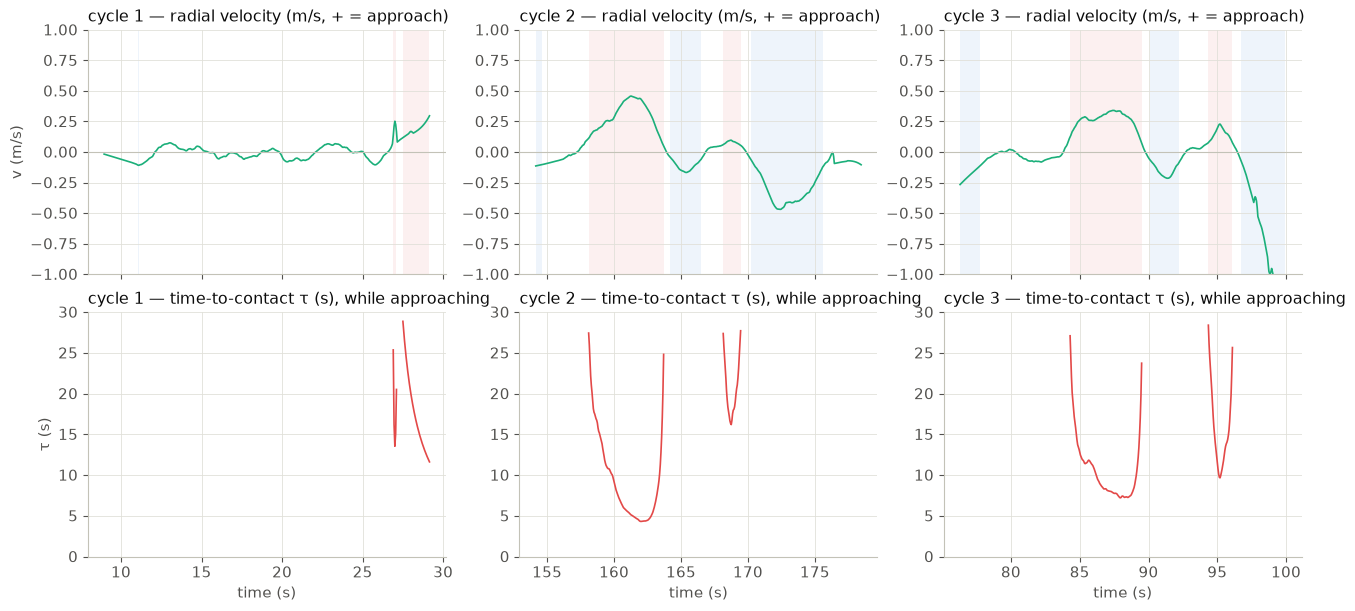

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex='col', constrained_layout=True)
for k, (nm, (ts, r, v, slope, tau)) in enumerate(CYCLES):
    ax = axes[0, k]
    ax.plot(ts, v, lw=1.2, color=COL["aqua"])
    ax.axhline(0, color=COL["baseline"], lw=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title(f"cycle {k + 1} — radial velocity (m/s, + = approach)")
    state = np.where(slope > DEADBAND, 1, np.where(slope < -DEADBAND, -1, 0))
    ax.fill_between(ts, -1, 1, where=state == 1, color=COL["red"], alpha=0.08, lw=0)
    ax.fill_between(ts, -1, 1, where=state == -1, color=COL["blue"], alpha=0.08, lw=0)
    ax = axes[1, k]
    ax.plot(ts, tau, lw=1.2, color=COL["red"])
    ax.set_ylim(0, 30)
    ax.set_title(f"cycle {k + 1} — time-to-contact τ (s), while approaching")
    ax.set_xlabel("time (s)")
    if np.any(~np.isnan(tau)):
        print(f"cycle {k + 1}: peak approach {np.nanmax(v):.2f} m/s, "
              f"peak recede {np.nanmin(v):.2f} m/s, min τ {np.nanmin(tau):.1f} s")
axes[0, 0].set_ylabel("v (m/s)")
axes[1, 0].set_ylabel("τ (s)")
plt.show()

Red fill = approaching, blue fill = receding: the state readout matches the
protocol (loom → hover near Spot → recede) in cycles 2 and 3. Cycle 1 stays in the
deadband — consistent with its flat level.

## Step 5 — live-ready tracker

Causal version: same math with one-sided smoothing (a 4-s rolling window and a linear
fit for the slope). Feed it `(level_dB, detected)` once per hop — both already exist in
`06_realtime_detector.py`'s loop, so wiring it in is ~5 lines. Suggested duck rule:

> **duck when detected AND (r < 1.5 m OR τ < 5 s)**

Below, the causal tracker replayed over the first file — it reproduces the offline arc
with a small lag (the price of one-sided smoothing).

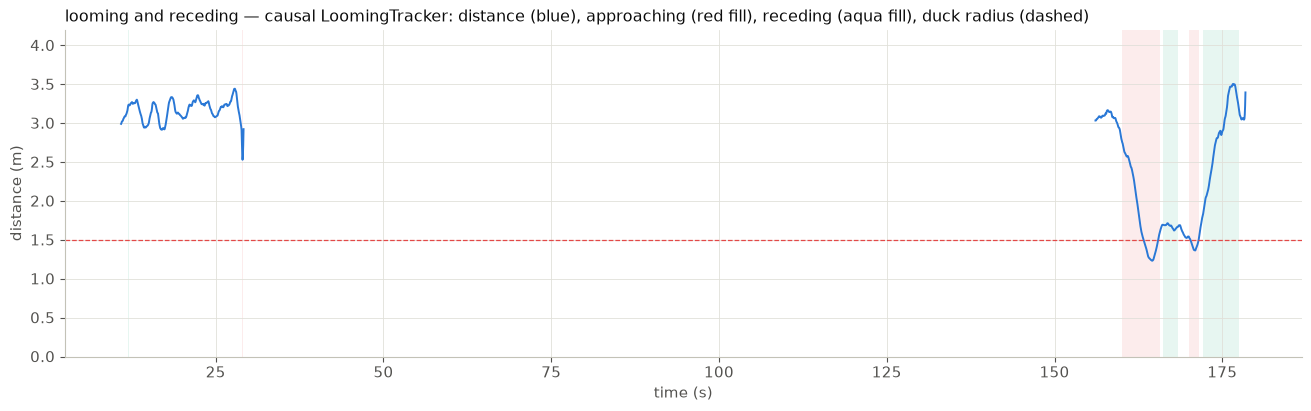

In [6]:
class LoomingTracker:
    """Causal distance / velocity / time-to-contact from the band level.
    Feed (level_db, detected) once per HOP_S; returns a dict while detected."""

    def __init__(self, floor_db, r0=R0):
        self.floor, self.r0 = floor_db, r0
        self.win = deque(maxlen=int(SLOPE_WIN_S / HOP_S))
        self.ref, self.t = None, 0.0

    def feed(self, level_db, detected):
        self.t += HOP_S
        if not detected:
            self.win.clear()
            self.ref = None
            return None
        Ld = 10 * np.log10(max(10 ** (level_db / 10) - 10 ** (self.floor / 10), 1e-12))
        self.win.append((self.t, Ld))
        if len(self.win) < int(REF_S / HOP_S):
            return None
        ts = np.array([w[0] for w in self.win])
        Ls = np.array([w[1] for w in self.win])
        if self.ref is None:
            self.ref = Ls.mean()                        # anchor: ~R0 at detection onset
        L_now = Ls[-int(1.0 / HOP_S):].mean()           # 1-s trailing mean
        r = self.r0 * 10 ** (-(L_now - self.ref) / 20)
        slope = np.polyfit(ts, Ls, 1)[0] if len(ts) > 40 else 0.0
        v = r * np.log(10) / 20 * slope
        state = ("approaching" if slope > DEADBAND
                 else "receding" if slope < -DEADBAND else "hover")
        tau = 8.686 / slope if slope > DEADBAND else np.inf
        return dict(r=r, v=v, tau=tau, state=state)

nm = "looming and receding"
t, lev, flag = runs[nm]
trk = LoomingTracker(FLOOR[nm])
out = [(tt, m["r"], m["state"]) for tt, l, f in zip(t, lev, flag)
       if (m := trk.feed(l, f))]
tt = np.array([o[0] for o in out])
rr = np.array([o[1] for o in out])
st = np.array([o[2] for o in out])

fig, ax = plt.subplots(figsize=(13, 4), constrained_layout=True)
brk = np.where(np.diff(tt) > 1)[0] + 1
for a, b in zip(np.r_[0, brk], np.r_[brk, len(tt)]):
    ax.plot(tt[a:b], rr[a:b], lw=1.4, color=COL["blue"])
for s, c in [("approaching", COL["red"]), ("receding", COL["aqua"])]:
    ax.fill_between(tt, 0, 4.2, where=st == s, color=c, alpha=0.10, lw=0)
ax.axhline(1.5, color=COL["red"], lw=0.9, ls="--")
ax.set_ylim(0, 4.2)
ax.set_title(f"{nm} — causal LoomingTracker: distance (blue), approaching (red fill), "
             "receding (aqua fill), duck radius (dashed)")
ax.set_xlabel("time (s)"); ax.set_ylabel("distance (m)")
plt.show()

## Summary

| cycle | file | closest | peak approach | min τ | note |
|---|---|---|---|---|---|
| 1 | looming… (first block) | ~3 m (no approach) | — | — | level flat: this pass never closed on the mic |
| 2 | looming… (second block) | **1.2 m** | 0.5 m/s | 4.3 s | textbook loom–hover–recede arc |
| 3 | looming…-2 | **1.6 m** | 0.35 m/s | 7 s | two gentle approach pulses |

**What works:** band-limited loudness (8–16 kHz, floor-subtracted) is a usable relative
range signal; its slope gives approach/recede state and a calibration-free
time-to-contact τ. All causal, all cheap, drops into the live script.

**What doesn't:** the whitened detector score and the comb correlation (loudness-blind
by design — they answer *is it there*, not *how far*); Doppler (15× smaller than the
rotors' own RPM wobble).

**Error budget / caveats:** ±3 dB of throttle & directivity ⇒ ×1.4 on distance; the 3-m
anchor assumes the protocol's takeoff point; any loud 8–16 kHz source *while the drone
flies* biases the level (rare — crowd doesn't reach that band); τ needs a few seconds of
steady closing to be meaningful (4-s slope window). If real accuracy is ever needed:
calibrate level↔distance once with a tape measure, or add a second microphone.

**Suggested duck rule:** `detected AND (r < 1.5 m OR τ < 5 s)` — in cycle 2 it fires at
~161 s via the τ arm, ~3 s before the closest approach (the r arm follows at ~163 s).
Cycle 3 (closest 1.6 m, min τ 7 s) stays outside both — the drone never really got
close on that pass; widen the duck radius if that should count as a threat.